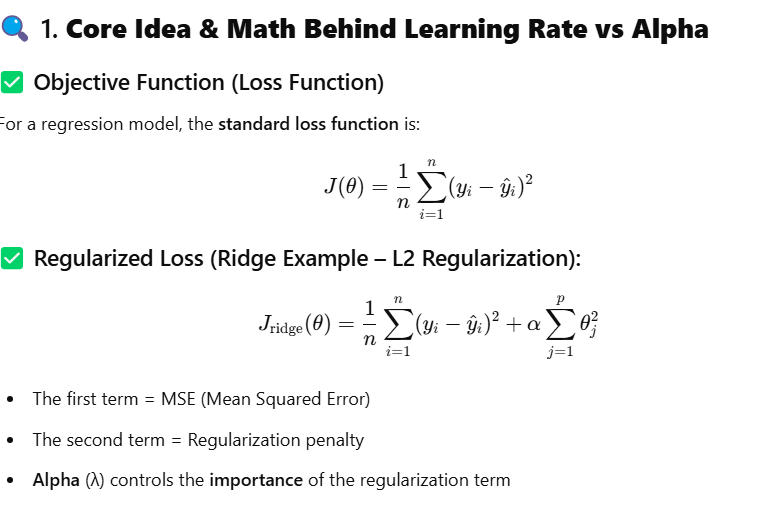

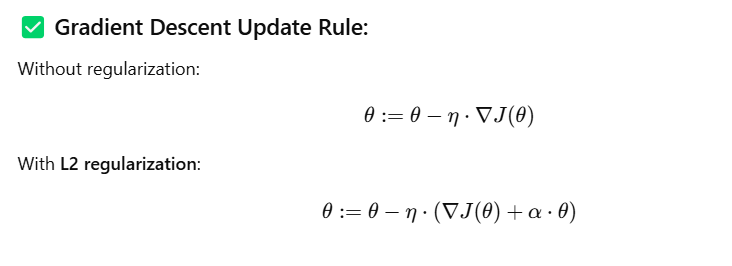

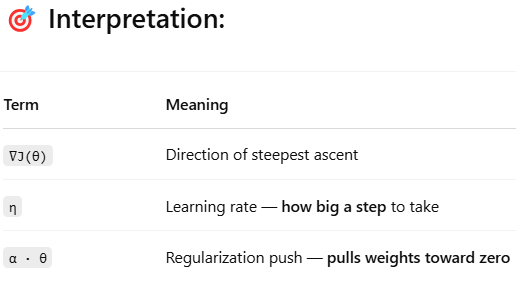

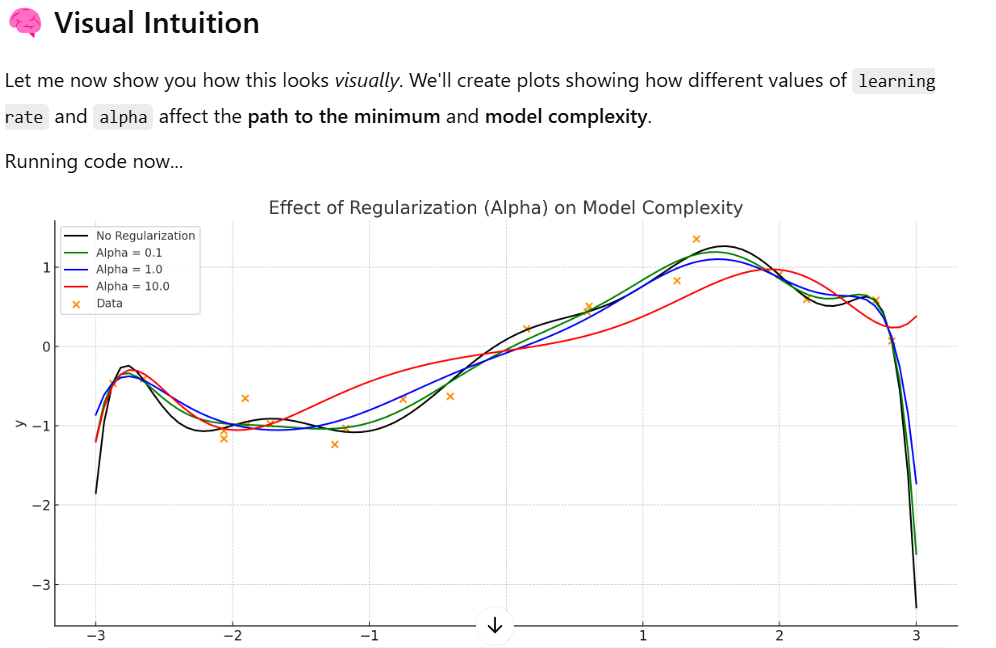

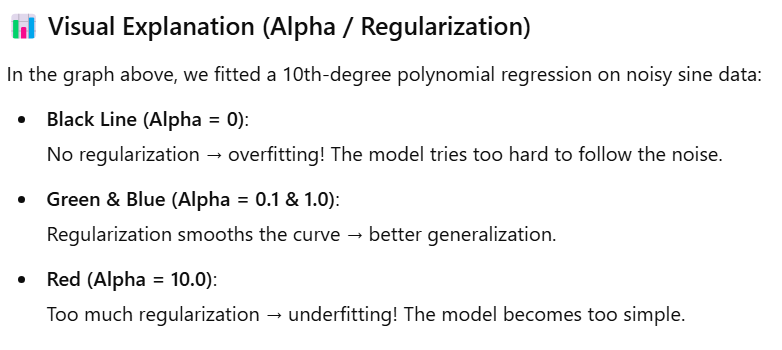

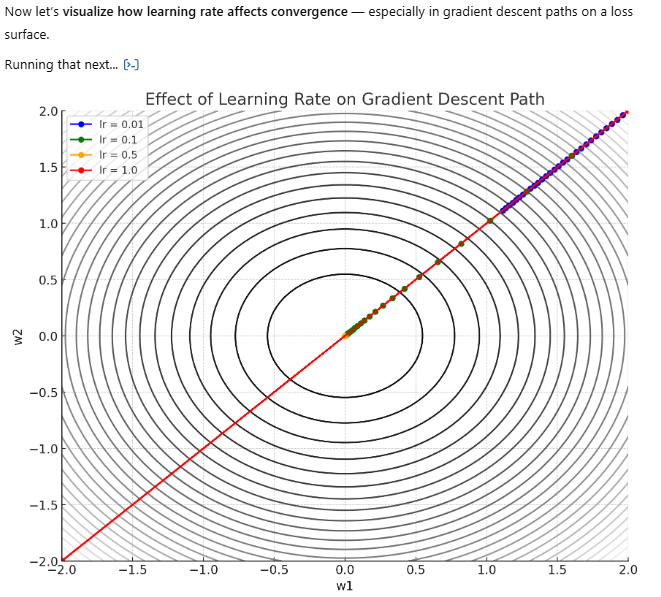

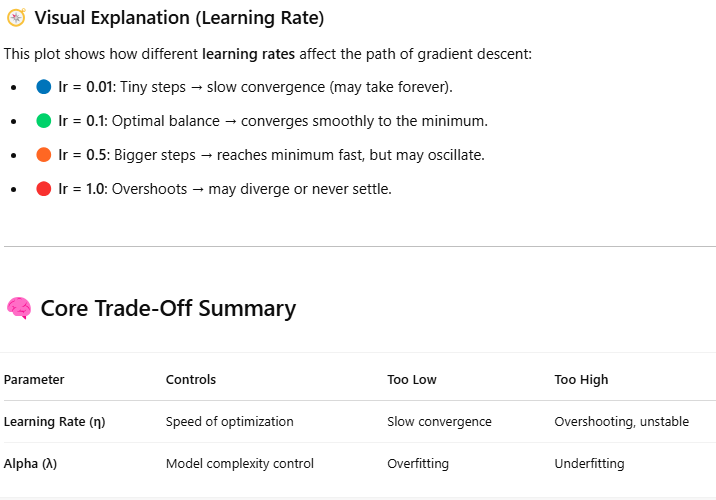

Optimal parameters (theta): 
[[4.21509609]
 [2.77011344]]


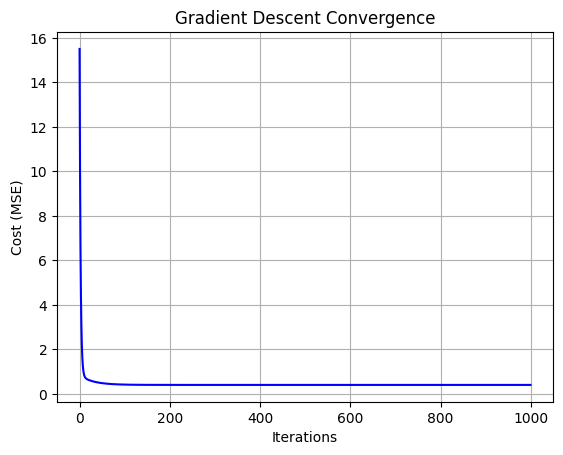

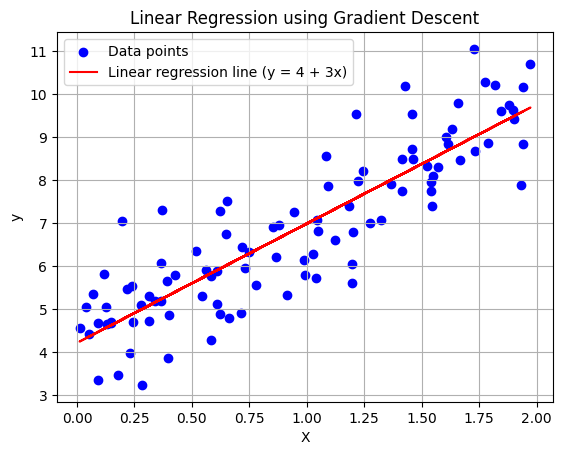

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some synthetic data (y = 2x + 1 + noise)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # Random data (100 samples, 1 feature)
y = 4 + 3 * X + np.random.randn(100, 1)  # Linear relation with some noise

# Add a bias term (x0 = 1) to each data point (homogeneous coordinates)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Gradient Descent Function
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m = len(X)
    theta = np.random.randn(2, 1)  # Random initial values for parameters

    # History to track the cost (loss) for each iteration
    cost_history = []

    for iteration in range(iterations):
        # Compute the predictions (y_pred)
        y_pred = X.dot(theta)

        # Compute the cost (Mean Squared Error)
        cost = (1 / (2 * m)) * np.sum(np.square(y_pred - y))
        cost_history.append(cost)

        # Calculate the gradient
        gradients = (1 / m) * X.T.dot(y_pred - y)

        # Update the parameters (theta)
        theta = theta - learning_rate * gradients

    return theta, cost_history

# Run gradient descent to optimize parameters
learning_rate = 0.1
iterations = 1000
theta_optimal, cost_history = gradient_descent(X_b, y, learning_rate, iterations)

# Print the optimal parameters
print(f"Optimal parameters (theta): \n{theta_optimal}")

# Plot the cost history over iterations to visualize convergence
plt.plot(range(iterations), cost_history, color='b')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()

# Plot the original data and the linear regression line
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, X_b.dot(theta_optimal), color='red', label='Linear regression line (y = 4 + 3x)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression using Gradient Descent')
plt.grid(True)
plt.show()




### **Tricky Question:**
**"You are training a linear regression model using gradient descent. How does the learning rate and regularization parameter (alpha) interact with each other? What would happen if you set the learning rate too high or the regularization parameter too large? Can they compensate for each other?"**

### **Answer:**

This question tests your understanding of optimization techniques in machine learning, particularly gradient descent, and the impact of regularization (alpha) on model training.

---

**1. Learning Rate and Regularization Overview:**

- **Learning Rate**: Controls the step size during the optimization process. A high learning rate might cause the gradient descent to "overshoot" the optimal values, making the model unstable, while a small learning rate might make the model converge very slowly.
  
- **Regularization (Alpha)**: Controls the strength of the penalty added to the cost function, typically to prevent overfitting. In **Ridge regression**, for example, L2 regularization (where alpha is the regularization strength) discourages large weights by adding a penalty term to the loss function.

**Cost Function in Ridge Regression:**
\[
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( y^{(i)} - \hat{y}^{(i)} \right)^2 + \frac{\alpha}{2m} \sum_{j=1}^{n} \theta_j^2
\]
where:
- The first term is the Mean Squared Error (MSE),
- The second term is the regularization penalty (controlled by alpha).

---

**2. Interaction Between Learning Rate and Regularization:**

- **Impact of Learning Rate**:
    - **Too High**: If the learning rate is too large, the algorithm may fail to converge or may overshoot the optimal point. The model could oscillate or diverge.
    - **Too Low**: A very small learning rate leads to slow convergence, which increases the time required for training and might not reach the optimal solution within a reasonable number of iterations.

- **Impact of Regularization (Alpha)**:
    - **Too High**: If alpha is too large, the regularization term will dominate the cost function. This will cause the model to prioritize keeping the weights small, potentially leading to underfitting. The model will become too simplistic, and you might not capture the underlying patterns in the data.
    - **Too Low**: If alpha is too small or zero, the regularization will have little effect, and the model might overfit the training data, capturing noise or random fluctuations as patterns.

---

**3. Can Learning Rate and Regularization Compensate for Each Other?**

- **No**, they cannot completely compensate for each other.
    - If you increase the learning rate to counteract a too-high regularization term (alpha), the model might still face convergence issues or overshoot the optimal parameters.
    - If the learning rate is too small, compensating with a larger alpha might reduce the model’s complexity, but it won't solve the issue of slow convergence.

**Example Scenarios:**

1. **High Learning Rate and High Alpha**:
    - If both are high, the model might not converge properly. The large learning rate causes overshooting, while the high regularization term might suppress the model from fitting the data correctly, leading to both instability and underfitting.

2. **Low Learning Rate and Low Alpha**:
    - A very small learning rate can cause slow convergence, but a low regularization parameter means the model is more likely to overfit. So, the slow convergence might be acceptable, but overfitting is a risk.

3. **Balanced Approach**:
    - Ideally, you'd want to tune both parameters via cross-validation or grid search to find an optimal balance where the learning rate is large enough to converge efficiently, and alpha is strong enough to regularize but not so strong as to underfit the model.

---

**4. Summary of Key Points:**
- The **learning rate** affects how quickly the model converges.
- **Alpha** (regularization) controls model complexity by penalizing large coefficients.
- Both parameters need careful tuning.
- They **cannot** fully compensate for each other. If one is not optimal, the model will perform suboptimally.
- **Cross-validation** is typically used to select the best combination of these hyperparameters.

---

